# Russian Handwritten Letters — Clean Training Notebook

This notebook is a **clean final version** for working with the Kaggle dataset `tatianasnwrt/russian-handwritten-letters`.

It does **character classification** (recognizing a single handwritten Cyrillic letter from an image), which fits this dataset much better than TrOCR.

Workflow:
1. Install only the packages we need
2. Download the dataset from Kaggle
3. Build a dataframe from image files
4. Visualize samples
5. Train a small CNN in PyTorch
6. Evaluate accuracy
7. Preview predictions on a few images


In [52]:
# Install the exact packages needed for this notebook
%pip uninstall -y tf_keras tensorflow keras tensorflow-macos tensorflow-metal
%pip install -q kagglehub pandas matplotlib pillow scikit-learn torch torchvision


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Restart the kernel once after the install cell

In VS Code notebooks: click **Restart** after the install cell finishes, then run the notebook from the top.


In [53]:
import os
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [54]:
# Download the dataset from Kaggle
dataset_path = kagglehub.dataset_download("tatianasnwrt/russian-handwritten-letters")
dataset_path = Path(dataset_path)

print("Dataset downloaded to:")
print(dataset_path)


Dataset downloaded to:
/Users/demid/.cache/kagglehub/datasets/tatianasnwrt/russian-handwritten-letters/versions/18


In [55]:
# Quick file inspection
all_files = []
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        all_files.append(Path(root) / f)

print("Total files found:", len(all_files))
print("\nFirst 30 files:")
for p in all_files[:30]:
    print(p.relative_to(dataset_path))


Total files found: 14191

First 30 files:
all_letters_info.csv
all_letters_image/all_letters_image/31_27.png
all_letters_image/all_letters_image/02_201.png
all_letters_image/all_letters_image/17_344.png
all_letters_image/all_letters_image/14_287.png
all_letters_image/all_letters_image/16_157.png
all_letters_image/all_letters_image/25_52.png
all_letters_image/all_letters_image/29_208.png
all_letters_image/all_letters_image/12_215.png
all_letters_image/all_letters_image/30_169.png
all_letters_image/all_letters_image/03_95.png
all_letters_image/all_letters_image/17_422.png
all_letters_image/all_letters_image/21_408.png
all_letters_image/all_letters_image/04_293.png
all_letters_image/all_letters_image/06_143.png
all_letters_image/all_letters_image/07_350.png
all_letters_image/all_letters_image/04_287.png
all_letters_image/all_letters_image/06_157.png
all_letters_image/all_letters_image/07_344.png
all_letters_image/all_letters_image/12_201.png
all_letters_image/all_letters_image/03_81.png
a

In [56]:
# Build a dataframe from image files
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".gif", ".webp"}

rows = []
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        p = Path(root) / f
        if p.suffix.lower() in IMAGE_EXTS:
            # Assumption for this dataset:
            # parent folder name = class label
            label = p.parent.name
            rows.append({
                "image_path": str(p),
                "label": label,
            })

df = pd.DataFrame(rows)

print("Dataset shape:", df.shape)
display(df.head())

print("\nUnique labels:", df["label"].nunique())
print(sorted(df["label"].unique())[:50])


Dataset shape: (14190, 2)


,image_path,label
0,/Users/demid/.cache/kagglehub/datasets/tatiana...,all_letters_image
1,/Users/demid/.cache/kagglehub/datasets/tatiana...,all_letters_image
2,/Users/demid/.cache/kagglehub/datasets/tatiana...,all_letters_image
3,/Users/demid/.cache/kagglehub/datasets/tatiana...,all_letters_image
4,/Users/demid/.cache/kagglehub/datasets/tatiana...,all_letters_image



Unique labels: 1
['all_letters_image']


,count
label,
all_letters_image,14190


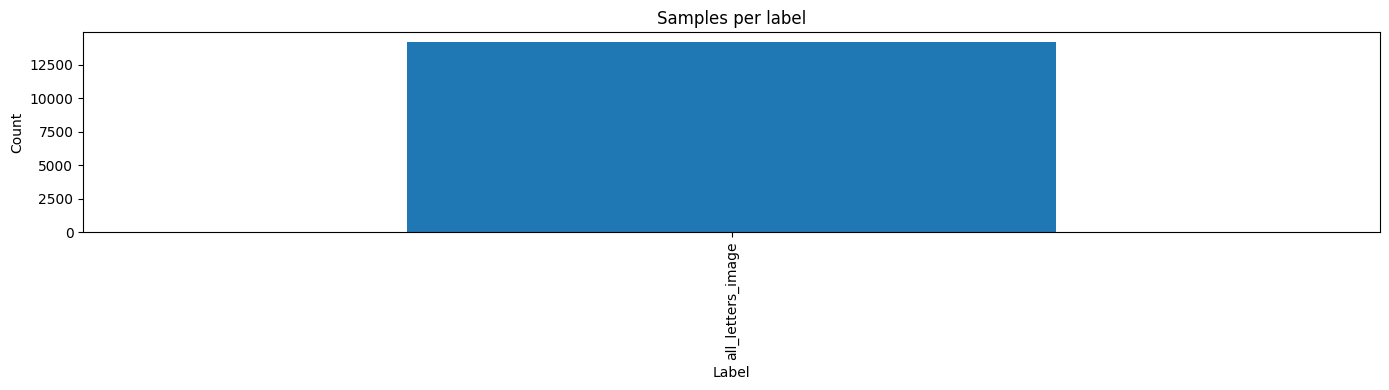

In [57]:
# Show class counts
label_counts = df["label"].value_counts().sort_index()
display(label_counts.to_frame("count").head(50))

plt.figure(figsize=(14, 4))
label_counts.plot(kind="bar")
plt.title("Samples per label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


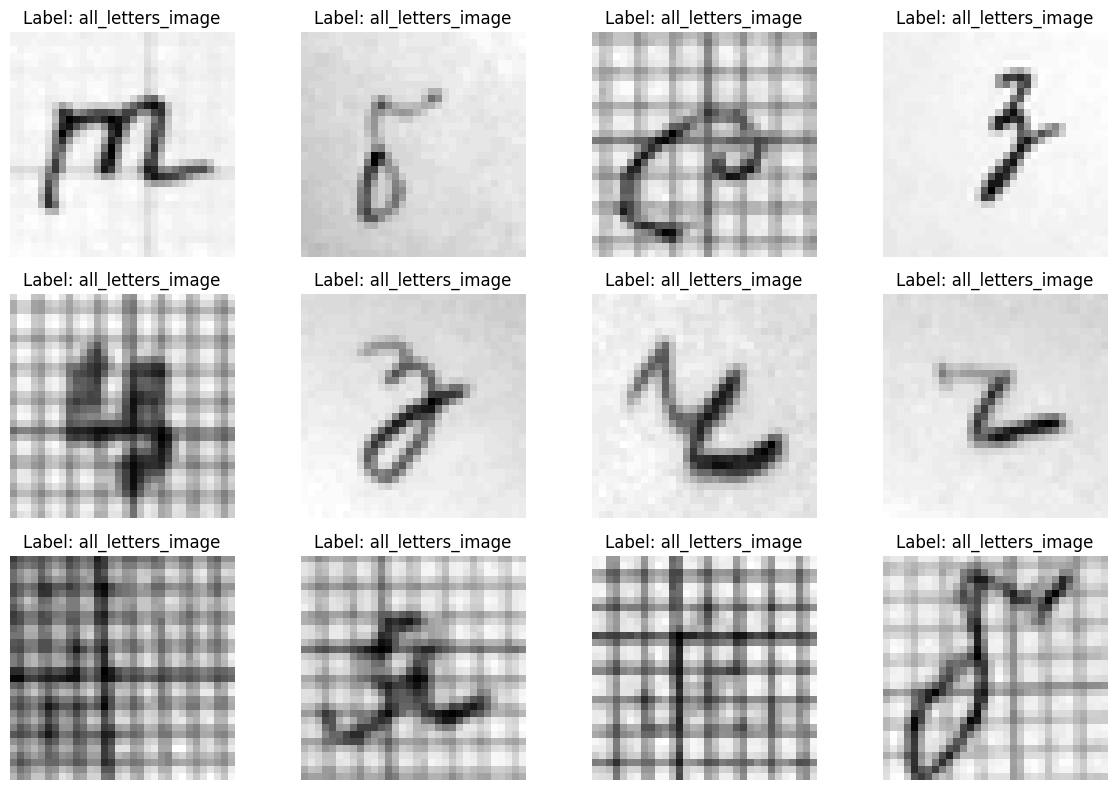

In [58]:
# Visualize a few random samples
sample_df = df.sample(min(12, len(df)), random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(12, 8))
for i, row in sample_df.iterrows():
    img = Image.open(row["image_path"]).convert("L")
    plt.subplot(3, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Label: {row['label']}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [59]:
# Encode labels as integers
label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["label"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("First classes:", class_names[:20])


Number of classes: 1
First classes: ['all_letters_image']


In [60]:
# Train/validation split
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label_id"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))


Train size: 11352
Validation size: 2838


In [61]:
# Image transforms
IMG_SIZE = 64
BATCH_SIZE = 64

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])


In [62]:
class HandwrittenLettersDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["image_path"]).convert("L")
        label = int(row["label_id"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label


In [63]:
train_dataset = HandwrittenLettersDataset(train_df, transform=train_transform)
val_dataset = HandwrittenLettersDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)  # [batch, channels, height, width]
print("Batch label shape:", labels.shape)


Batch image shape: torch.Size([64, 1, 64, 64])
Batch label shape: torch.Size([64])


In [64]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=num_classes).to(device)
print(model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)


In [65]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate_model(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


In [66]:
EPOCHS = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    val_loss, val_acc = evaluate_model(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )


Epoch 1/5 | train_loss=0.0000 train_acc=1.0000 | val_loss=0.0000 val_acc=1.0000
Epoch 2/5 | train_loss=0.0000 train_acc=1.0000 | val_loss=0.0000 val_acc=1.0000
Epoch 3/5 | train_loss=0.0000 train_acc=1.0000 | val_loss=0.0000 val_acc=1.0000
Epoch 4/5 | train_loss=0.0000 train_acc=1.0000 | val_loss=0.0000 val_acc=1.0000
Epoch 5/5 | train_loss=0.0000 train_acc=1.0000 | val_loss=0.0000 val_acc=1.0000


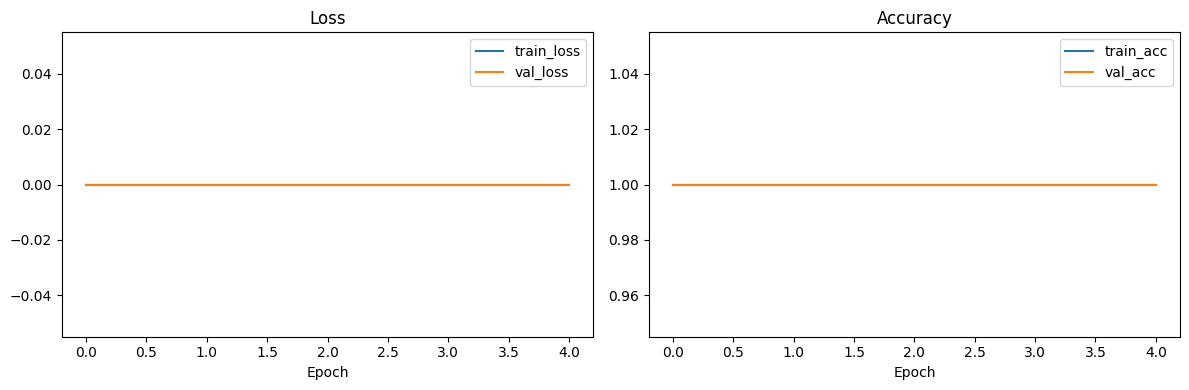

In [67]:
# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()


In [68]:
# Final validation metrics
val_loss, val_acc = evaluate_model(model, val_loader)
print(f"Final validation loss: {val_loss:.4f}")
print(f"Final validation accuracy: {val_acc:.4f}")


Final validation loss: 0.0000
Final validation accuracy: 1.0000


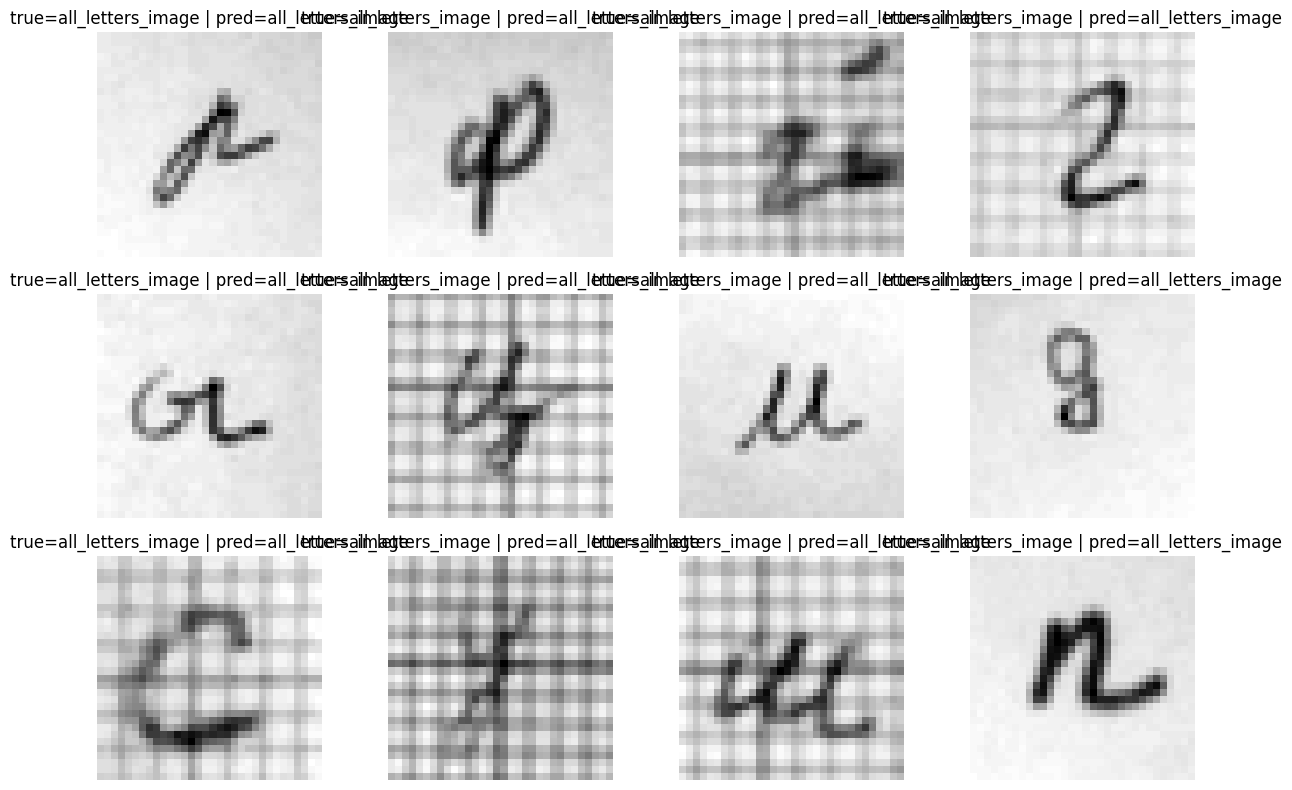

In [69]:
# Preview predictions on a few validation images
model.eval()
preview_df = val_df.sample(min(12, len(val_df)), random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(12, 8))
for i, row in preview_df.iterrows():
    image = Image.open(row["image_path"]).convert("L")
    tensor = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        pred_id = output.argmax(dim=1).item()

    pred_label = label_encoder.inverse_transform([pred_id])[0]
    true_label = row["label"]

    plt.subplot(3, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"true={true_label} | pred={pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [70]:
# Save the trained model and label classes
save_dir = Path("artifacts")
save_dir.mkdir(exist_ok=True)

model_path = save_dir / "russian_letters_cnn.pt"
classes_path = save_dir / "classes.txt"

torch.save(model.state_dict(), model_path)
with open(classes_path, "w", encoding="utf-8") as f:
    for name in class_names:
        f.write(name + "\n")

print("Saved model to:", model_path)
print("Saved classes to:", classes_path)


Saved model to: artifacts/russian_letters_cnn.pt
Saved classes to: artifacts/classes.txt


## Inference on one image

Use this cell after training to test a single image path.


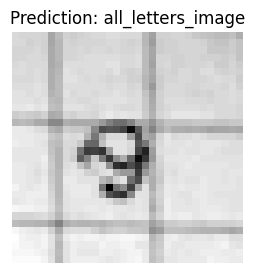

Image path: /Users/demid/.cache/kagglehub/datasets/tatianasnwrt/russian-handwritten-letters/versions/18/all_letters_image/all_letters_image/31_27.png
Predicted label: all_letters_image


In [71]:
# Replace with any image path from the dataset or your own test image
test_image_path = df.iloc[0]["image_path"]

image = Image.open(test_image_path).convert("L")
tensor = val_transform(image).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(tensor)
    pred_id = output.argmax(dim=1).item()

pred_label = label_encoder.inverse_transform([pred_id])[0]

plt.figure(figsize=(3, 3))
plt.imshow(image, cmap="gray")
plt.title(f"Prediction: {pred_label}")
plt.axis("off")
plt.show()

print("Image path:", test_image_path)
print("Predicted label:", pred_label)


In [72]:
import torch

# make sure model is on CPU
model = model.to("cpu")

# save trained weights
torch.save(model.state_dict(), "russian_letters_cnn.pth")

print("Model saved successfully")

Model saved successfully


In [73]:
print("Unique labels:", df["label"].nunique())
print("Labels:", sorted(df["label"].unique())[:50])
print(df["label"].value_counts().head(20))

Unique labels: 1
Labels: ['all_letters_image']
label
all_letters_image    14190
Name: count, dtype: int64


In [74]:
labels = sorted(df["label"].unique())
label_map = {label: i for i, label in enumerate(labels)}

print("Number of classes:", len(label_map))
print(label_map)

Number of classes: 1
{'all_letters_image': 0}
